In [15]:
import torch
from tianshou.data import Collector, VectorReplayBuffer
from tianshou.env import DummyVectorEnv
from tianshou.policy import DQNPolicy
from tianshou.trainer import OffpolicyTrainer
from dengue_envs.envs.dengue_diagnostics import DengueDiagnosticsEnv
from dengue_wrapper import DengueWrapper, CaseByCaseWrapper
from fcn_network import DengueNet

In [16]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 1e-4
GAMMA = 0.99
BUFFER_SIZE = 1000
BATCH_SIZE = 64
N_STEP = 3
TARGET_UPDATE_FREQ = 500
EPS_TRAIN_START = 1.0
EPS_TRAIN_FINAL = 0.05
EPS_TRAIN_DECAY = 10
EPS_TEST = 0.01

NUM_ENVS = 4
NUM_TEST_ENVS = 4
EPOCH = 1
STEP_PER_EPOCH = 20
STEP_PER_COLLECT = 10
UPDATE_PER_STEP = 0.1

In [17]:
def make_env():
    """Função factory para criar o ambiente com wrappers."""
    env = DengueDiagnosticsEnv(epilength=60, size=400)
    env = DengueWrapper(env)
    env = CaseByCaseWrapper(env)
    return env

Iniciando treinamento na cpu...


Epoch #1:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(


Epoch #1:  60%|######    | 12/20 [00:10<00:06,  1.18it/s, env_step=12, gradient_step=1, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1: 24it [00:13,  1.76it/s, env_step=24, gradient_step=2, len=0, n/ep=0, n/st=12, rew=0.00]                        


Epoch #1: test_reward: 1471.500000 ± 5.024938, best_reward: 1471.500000 ± 5.024938 in #1

--- Resultado do Treinamento ---
InfoStats(gradient_step=2, best_reward=1471.5, best_reward_std=5.024937810560445, train_step=24, train_episode=np.int64(0), test_step=2944, test_episode=np.int64(8), timing=TimingStats(total_time=1454.3149790763855, train_time=14.07567811012268, train_time_collect=6.601314544677734, train_time_update=6.701247930526733, test_time=1440.2393009662628, update_speed=1.7050688295251746))
Política salva em dqn_dengue_policy.pth


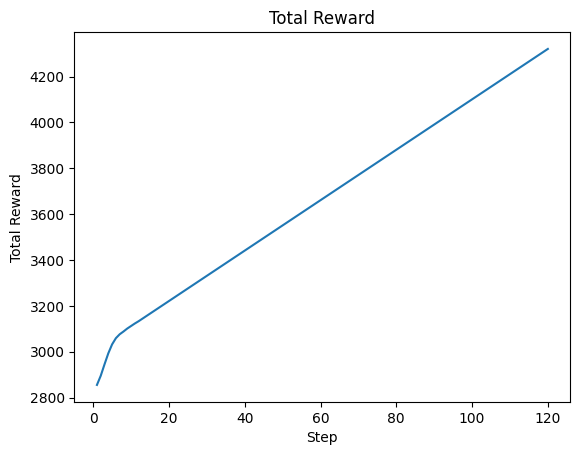

In [18]:
if True:
    train_envs = DummyVectorEnv([make_env for _ in range(NUM_ENVS)])
    test_envs = DummyVectorEnv([make_env for _ in range(NUM_TEST_ENVS)])

    env = make_env()
    map_shape = env.observation_space.spaces["map"].shape
    action_shape = env.action_space.n

    net = DengueNet(map_shape, action_shape, device=DEVICE).to(DEVICE)
    optim = torch.optim.Adam(net.parameters(), lr=LR)

    policy = DQNPolicy(
        model=net,
        optim=optim,
        discount_factor=GAMMA,
        estimation_step=N_STEP,
        target_update_freq=TARGET_UPDATE_FREQ,
        action_space=env.action_space
    )

    buffer = VectorReplayBuffer(
        total_size=BUFFER_SIZE,
        buffer_num=NUM_ENVS,
        ignore_obs_next=True
    )

    train_collector = Collector(
        policy, train_envs, buffer, exploration_noise=True
    )
    test_collector = Collector(policy, test_envs)


    def train_fn(epoch, env_step):
        if env_step <= EPS_TRAIN_DECAY:
            eps = EPS_TRAIN_START - env_step / EPS_TRAIN_DECAY * \
                  (EPS_TRAIN_START - EPS_TRAIN_FINAL)
        else:
            eps = EPS_TRAIN_FINAL
        policy.set_eps(eps)


    def test_fn(epoch, env_step):
        policy.set_eps(EPS_TEST)

    trainer = OffpolicyTrainer(
        policy=policy,
        train_collector=train_collector,
        test_collector=test_collector,
        max_epoch=EPOCH,
        step_per_epoch=STEP_PER_EPOCH,
        step_per_collect=STEP_PER_COLLECT,
        update_per_step=UPDATE_PER_STEP,
        episode_per_test=NUM_TEST_ENVS,
        batch_size=BATCH_SIZE,
        train_fn=train_fn,
        test_fn=test_fn,
        stop_fn=lambda mean_rewards: mean_rewards >= 20
    )

    print(f"Iniciando treinamento na {DEVICE}...")
    result = trainer.run()
    print("\n--- Resultado do Treinamento ---")
    print(result)

    torch.save(policy.state_dict(), "dqn_dengue_policy2.pth")
    print("Política salva em dqn_dengue_policy.pth")